# Imports

In [108]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Helper functions

In [109]:
def det(X):
  return np.linalg.det(X)

def inv(X):
  return np.linalg.inv(X)

# Basis functions

In [110]:
def identity_bf(X):
  return X

def radial_bf(X, centers, lambdaval):
  d = X[:, np.newaxis] - centers[np.newaxis, :]
  y = np.exp(-0.5 * (d ** 2) / lambdaval)
  return y

def polynomial_bf(X, pow):
  return X ** pow

# Load and format data

In [111]:
real_data = pd.read_csv("./data/vattuniemi.csv")
generated_data = pd.read_csv("./data/generated_data.csv")

# Toggle switch to use either real or simulated data
data = real_data
#display(data)

# Choose features
X = data[["Area", "Volume", "Storeys"]]
# Uncomment in order to scale down to achieve sufficient accuracy for radial bf's
#X["Area"] = X["Area"].map(lambda area: area / 10000)
#X["Volume"] = X["Volume"].map(lambda volume: volume / 10000)
X = X.values

# Choose labels
concrete = data[["Concrete"]].values
mineral_wool = data[["Mineral_wool"]].values
metal = data[["Metal"]].values
glass = data[["Glass"]].values


# Implement Bayesian linear regression

In [112]:
def BLR(X, y, alpha, beta, mu_0):

  N, F = X.shape

  # Posterior mean mu and covariance matrix S
  S_inv = beta * (X.T @ X) + alpha * np.identity(F)
  S = inv(S_inv)
  mu = S @ ((beta * X.T @ y).flatten() + alpha * mu_0)

  # Log-likelihood (Barber 18.1.19)
  d = (beta * X.T @ y).flatten() + alpha * mu_0
  
  log_lik = 0.5 * (-beta * y.T @ y + d.T @ S @ d + np.log(det(2 * np.pi * S))
            + F * np.log(alpha) + N * np.log(beta) - N * np.log(2 * np.pi))
            
  # Optional implementations of log-likelihood (not verified)
  #log_lik = -0.5 * np.log(det(2 * np.pi * S)) - 0.5 * y.T @ S_inv
  #log_lik = 0.5 * (-beta * y.T @ y + d.T @ S @ d)

  return mu, S, log_lik

# Fit & test

,Parameter,Value
0,alpha,0.000008
1,beta,0.00001
2,mu0,"[3, 16, 5]"


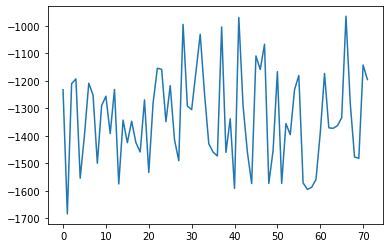

In [113]:
# Grid search over hyperparameter values
area_mu_0 = range(3,6)
volume_mu_0 = range(15,23)
storeys_mu_0 = range(3,6)
alphas = np.linspace(0.000001, 0.00001, 10)
betas = np.linspace(0.00001, 0.001, 10)
best_log_lik = -np.inf
logliks = []
# Replace with {concrete, mineral_wool, glass, metal}
y = concrete

for area_mu in area_mu_0:
  for volume_mu in volume_mu_0:
    for storeys_mu in storeys_mu_0:
      for alpha in alphas:
        for beta in betas:
          res = np.zeros(10)
          mu_0 = np.array([area_mu, volume_mu, storeys_mu])
          # Average log-likelihood over 10 different fits for each hyperparameter setting
          for i in range(10):

            X_tr, X_tst, y_tr, y_tst = train_test_split(
                X, y, test_size=0.3)

            X_input = identity_bf(X_tr)
            X_test = identity_bf(X_tst)
            post_mu, post_S, log_lik = BLR(
                X_input, y_tr, alpha, beta, mu_0)

            res[i] = log_lik

          mean_loglik = np.mean(res)
          logliks.append(mean_loglik)

          if mean_loglik > best_log_lik:
            best_log_lik = mean_loglik
            best_alpha = alpha
            best_beta = beta
            best_mu_0 = mu_0

# Store optimal hyperparameter values
params = pd.DataFrame({
    'Parameter': ['alpha', 'beta', 'mu0'],
    'Value': [best_alpha, best_beta, best_mu_0]
})

# Show rough log-likelihood behavior during grid search
plt.plot(logliks[::100].copy())

display(params)


# Test runs on varying splits

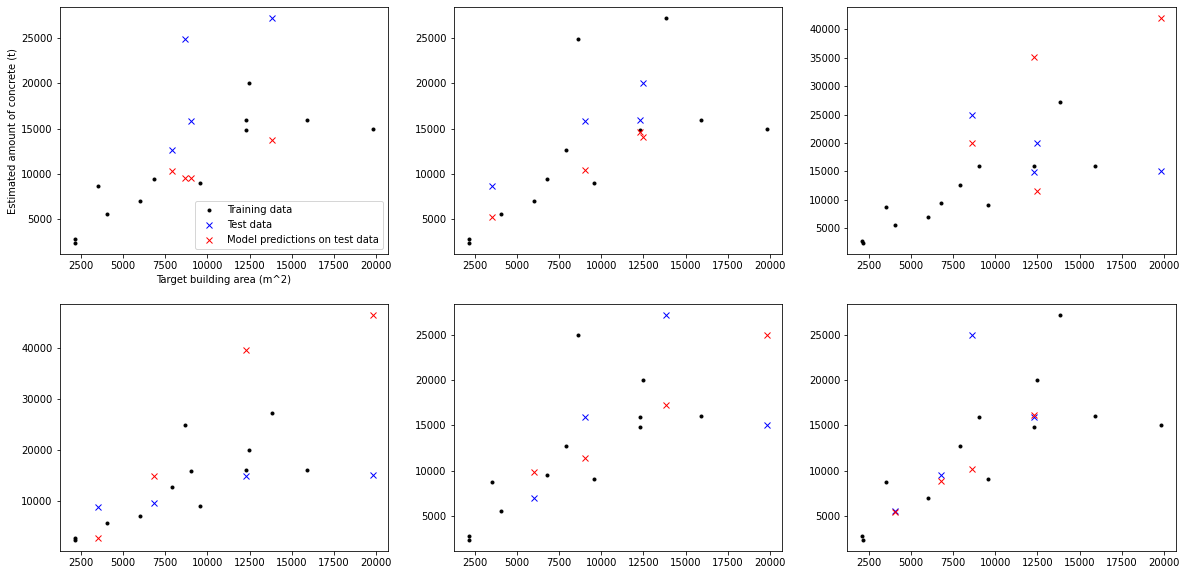

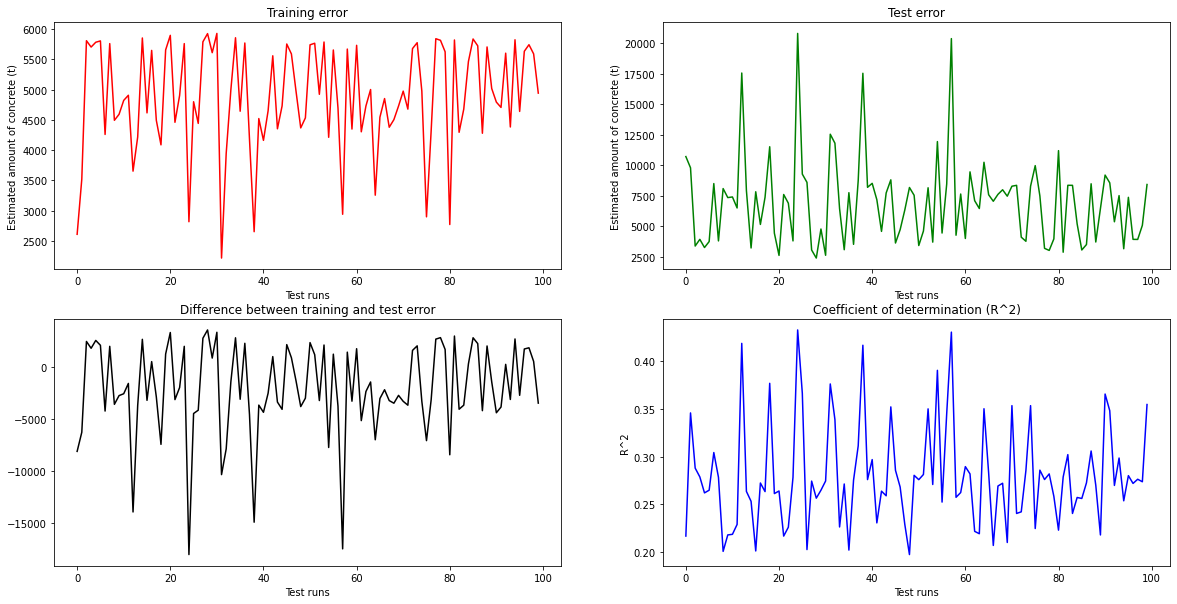

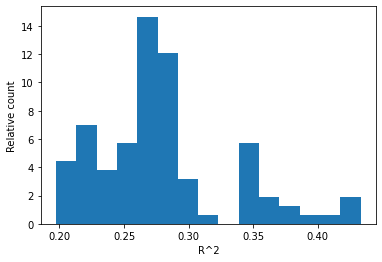

In [114]:
n_runs = 100
errs = np.zeros(n_runs)
errs_tr = np.zeros(n_runs)
scores = np.zeros(n_runs)
plt.figure(figsize=[20, 10])
j = 0

# Fit and test model with optimal hyperparams with 6 different splits
for i in range(n_runs):
  X_tr, X_tst, y_tr, y_tst = train_test_split(
      X, y, test_size=0.2)

  X_input = identity_bf(X_tr)
  X_test = identity_bf(X_tst)
  best_mu, best_S, loglik = BLR(
      X_input, y_tr, best_alpha, best_beta, best_mu_0)

  y_pred = X_test @ best_mu
  errs[i] = np.sqrt(mean_squared_error(y_tst, y_pred))
  errs_tr[i] = np.sqrt(mean_squared_error(y_tr, X_tr @ best_mu))

  # Compute R^2
  var_pred = np.var(X @ best_mu)
  var_res = np.var(y - X @ best_mu)
  scores[i] = var_pred / (var_pred + var_res)

  if i % 19 == 0:
    plt.subplot(230 + j + 1)
    plt.plot(X_tr[:, 0], y_tr, '.k', label='Training data')
    plt.plot(X_tst[:, 0], y_tst, 'bx', label='Test data')
    plt.plot(X_tst[:, 0], y_pred, 'rx',
            label='Model predictions on test data')
    if j == 0:
        plt.xlabel('Target building area (m^2)')
        plt.ylabel('Estimated amount of concrete (t)')
        plt.legend()
    j += 1

# Print and plot results
plt.show()
plt.figure(figsize=[20, 10])
plt.subplot(221)
plt.xlabel('Test runs')
plt.ylabel('Estimated amount of concrete (t)')
plt.title('Training error')
plt.plot(errs_tr, 'r-')
plt.subplot(222)
plt.xlabel('Test runs')
plt.ylabel('Estimated amount of concrete (t)')
plt.title('Test error')
plt.plot(errs, 'g-')
plt.subplot(223)
plt.xlabel('Test runs')
plt.title('Difference between training and test error')
plt.plot(errs_tr - errs, 'k-')
plt.subplot(224)
plt.xlabel('Test runs')
plt.ylabel('R^2')
plt.title('Coefficient of determination (R^2)')
plt.plot(scores, 'b-')
plt.show()

plt.figure()
plt.hist(scores, bins=15, density=True)
plt.xlabel('R^2')
plt.ylabel('Relative count')
plt.show()


# Predictive distribution using simple posterior sampling

In [115]:
def predict(x, sample_size=1000, confidence=0.95):

  weight_samples = np.random.multivariate_normal(
      best_mu, best_S, size=sample_size)
  preds = weight_samples @ x
  pred_mean = np.mean(preds)
  q_1 = np.quantile(preds, 1-confidence)
  q_2 = np.quantile(preds, confidence)

  prediction = {
      "Prediction mean": pred_mean,
      "Confidence": confidence,
      "Interval": (q_1, q_2)
  }

  return prediction


print(best_S)

test_input = X_tst[0, :]
test_real_out = y_tst[0].item()
pred = predict(test_input)
print("Input:")
print(test_input)
print("Actual value:")
print(test_real_out)
print("Prediction:")
print(pred)


[[ 9.40288120e-03 -2.47904972e-03 -8.59887262e-01]
 [-2.47904972e-03  7.11476499e-04 -1.99524129e-01]
 [-8.59887262e-01 -1.99524129e-01  3.62591060e+03]]
Input:
[ 6012 19693     5]
Actual value:
7016.0
Prediction:
{'Prediction mean': 8725.408585898447, 'Confidence': 0.95, 'Interval': (8465.255060764799, 9012.472568421697)}
